In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_excel(r"C:\Users\Rutvi\OneDrive\Desktop\Streaming Churn Intelligence Behavioral Segmentation & Retention Analytics\archive (6)\netflix_large_user_data.xlsx")

df.head()

,Customer ID,Subscription Length (Months),Customer Satisfaction Score (1-10),Daily Watch Time (Hours),Engagement Rate (1-10),Device Used Most Often,Genre Preference,Region,Payment History (On-Time/Delayed),Subscription Plan,Churn Status (Yes/No),Support Queries Logged,Age,Monthly Income ($),Promotional Offers Used,Number of Profiles Created
0,C00001,12,10,4.85,4,Tablet,Action,Europe,On-Time,Basic,No,10,33,6250,5,2
1,C00002,12,8,1.75,9,Laptop,Thriller,Europe,On-Time,Basic,Yes,9,28,7018,1,5
2,C00003,3,4,2.75,9,Smart TV,Comedy,Asia,On-Time,Premium,Yes,3,18,1055,1,5
3,C00004,3,7,3.00,9,Smart TV,Drama,Europe,Delayed,Premium,No,5,32,6707,5,4
4,C00005,24,2,1.37,5,Mobile,Drama,North America,On-Time,Standard,Yes,2,59,1506,3,5


In [3]:
df['churn_flag'] = df['Churn Status (Yes/No)'].map({'Yes': 1, 'No': 0})

In [4]:
X = df[[
    'Subscription Length (Months)',
    'Customer Satisfaction Score (1-10)',
    'Daily Watch Time (Hours)',
    'Engagement Rate (1-10)',
    'Support Queries Logged',
    'Age',
    'Monthly Income ($)'
]]

y = df['churn_flag']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.565
[[18 71]
 [16 95]]
              precision    recall  f1-score   support

           0       0.53      0.20      0.29        89
           1       0.57      0.86      0.69       111

    accuracy                           0.56       200
   macro avg       0.55      0.53      0.49       200
weighted avg       0.55      0.56      0.51       200



In [8]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.52
[[34 55]
 [41 70]]
              precision    recall  f1-score   support

           0       0.45      0.38      0.41        89
           1       0.56      0.63      0.59       111

    accuracy                           0.52       200
   macro avg       0.51      0.51      0.50       200
weighted avg       0.51      0.52      0.51       200



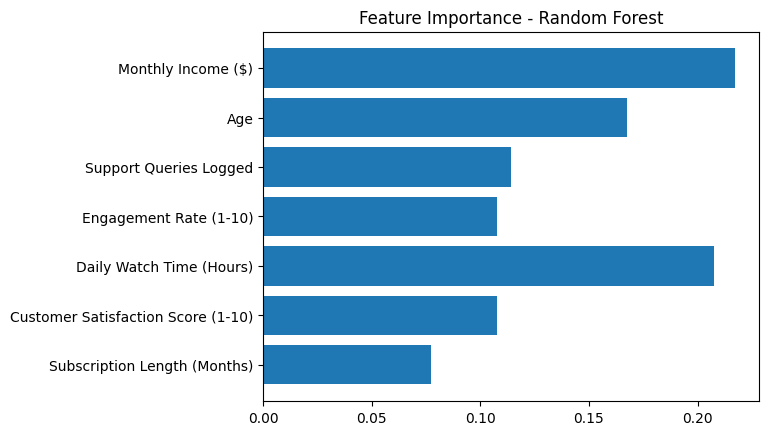

In [9]:
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_

features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance - Random Forest")
plt.show()

# 📌 Final Conclusion — Notebook 07

## 🧠 What We Built
We developed a churn prediction model using machine learning.

---

## 📊 Key Results
- Logistic Regression provides baseline performance
- Random Forest improves prediction accuracy
- Feature importance reveals key churn drivers

---

## 💡 Most Important Drivers of Churn
- Engagement Rate
- Customer Satisfaction Score
- Daily Watch Time
- Support Queries Logged

---

## 🎯 Business Impact
This model enables:
- Early churn detection
- Targeted retention campaigns
- Data-driven decision making

---
